In [5]:
file_paths = paths = [
    "/data1/shypula/prog_diversity/all_experiments/NewDatasetReevaluation_2025-03-17_23-25-29/driver_stats_two_shot_removed.tsv",
    "/data1/shypula/prog_diversity/all_experiments/NewDatasetFixTwoShot_2025-03-21_18-30-20/driver_stats.tsv",
    "/data1/shypula/prog_diversity/all_experiments/NewDatasetFixTwoShot_2025-03-21_18-13-34/driver_stats.tsv",
    "/data1/shypula/prog_diversity/all_experiments/NewDatasetFixTwoShot_2025-03-23_17-41-09/driver_stats.tsv",
    "/data1/shypula/prog_diversity/all_experiments/NewDatasetReRunErrors_2025-03-25_09-44-37/driver_stats.tsv",
    # "/data1/shypula/prog_diversity/all_experiments/NewDatasetSizeSweep_2025-03-26_03-15-15/driver_stats.tsv",
    # "/data5/shypula/program_cal_diverse/open_ended/NewDatasetSizeSweep_2025-03-26_16-43-02/driver_stats.tsv", # new file

    # "/data1/shypula/prog_diversity/all_experiments/NewDatasetSizeSweep_2025-03-25_01-08-23/driver_stats.tsv",
]

In [6]:
import pandas as pd

reference_columns = None
mismatched_files = []
dataframes = []
for file in file_paths:
    try:
        header_df = pd.read_csv(file, sep="\t", nrows=0)  # read only header
        columns = list(header_df.columns)

        if reference_columns is None:
            reference_columns = columns
        elif columns != reference_columns:
            mismatched_files.append((file, columns))
        
        df = pd.read_csv(file, sep="\t")
        dataframes.append(df)
    except Exception as e:
        print(f"⚠️ Error reading {file}: {e}")

print("Mismatched files:", mismatched_files)
print(reference_columns)

Mismatched files: []
['model', 'template', 'temperature', 'top_p', 'num_return_sequences', 'all_coherence', 'all_coh_semantic_count', 'all_coh_semantic_prop_of_all', 'all_semantic_count_incl_incoherent', 'all_semantic_proportion_incl_incoherent', 'all_pairwise_semantic_prop_incl_incoherent', 'all_accuracy', 'all_semantic_count_wcoh', 'all_semantic_proportion_wcoh', 'all_semantic_count_wcoh_nonempty', 'all_semantic_proportion_wcoh_nonempty', 'all_semantic_count_wcoh_nonempty_woutput', 'all_semantic_proportion_wcoh_nonempty_woutput', 'all_pairwise_semantic_prop_wcoh', 'all_pairwise_semantic_prop_wcoh_nonempty', 'all_pairwise_semantic_prop_wcoh_nonempty_woutput', 'all_average_cosine_distance_programs', 'all_average_cosine_distance_raw', 'all_average_cosine_distance_programs_zero_null', 'all_average_cosine_distance_raw_zero_null', 'all_average_cosine_distance_programs_one_null', 'all_average_cosine_distance_raw_one_null', 'all_distinct_1', 'all_distinct_2', 'all_distinct_3', 'all_distinct_

In [7]:
if dataframes:
    data = pd.concat(dataframes, ignore_index=True)
print(len(data))

74


In [8]:
all_models = data["model"].unique()
print(all_models)
print("Num of models:", len(all_models))

['allenai/tulu-2-70b' 'meta-llama/Llama-3.1-70B'
 'meta-llama/Llama-2-70b-hf' 'meta-llama/Llama-2-70b-chat-hf'
 'allenai/Llama-3.1-Tulu-3-70B-SFT' 'allenai/tulu-2-dpo-70b'
 'meta-llama/Llama-3.1-8B' 'allenai/Llama-3.1-Tulu-3-70B-DPO'
 'meta-llama/Llama-3.1-70B-Instruct' 'meta-llama/Llama-3.1-8B-Instruct'
 'allenai/Llama-3.1-Tulu-3-8B-SFT' 'allenai/Llama-3.1-Tulu-3-8B-DPO'
 'allenai/Llama-3.1-Tulu-3.1-8B' 'allenai/tulu-2-7b'
 'meta-llama/Llama-2-7b-hf' 'meta-llama/Llama-2-7b-chat-hf'
 'allenai/tulu-2-dpo-7b' 'allenai/Llama-3.1-Tulu-3-70B'
 'allenai/Llama-3.1-Tulu-3-8B']
Num of models: 19


In [23]:
by_model_family = {
    "LLaMA 2 7B": {
        "meta-llama/Llama-2-7b-hf": "Base",
        "allenai/tulu-2-7b": "SFT",
        "allenai/tulu-2-dpo-7b": "DPO",
        "meta-llama/Llama-2-7b-chat-hf": "RL",
    },
    "LLaMA 2 70B": {
        "meta-llama/Llama-2-70b-hf": "Base",
        "allenai/tulu-2-70b": "SFT",
        "allenai/tulu-2-dpo-70b": "DPO", 
        "meta-llama/Llama-2-70b-chat-hf": "RL",
    },
    "LLaMA 3.1 8B": {
        "meta-llama/Llama-3.1-8B": "Base",
        "allenai/Llama-3.1-Tulu-3-8B-SFT": "SFT",
        "meta-llama/Llama-3.1-8B-Instruct": "DPO",
        "allenai/Llama-3.1-Tulu-3-8B-DPO": "DPO",
        "allenai/Llama-3.1-Tulu-3-8B": "RL",
        "allenai/Llama-3.1-Tulu-3.1-8B": "RL",
    },
    "LLaMA 3.1 70B": {
        "meta-llama/Llama-3.1-70B": "Base",
        "allenai/Llama-3.1-Tulu-3-70B-SFT": "SFT",
        "meta-llama/Llama-3.1-70B-Instruct": "DPO",
        "allenai/Llama-3.1-Tulu-3-70B-DPO": "DPO",
        "allenai/Llama-3.1-Tulu-3-70B": "RL",
    }
}

In [24]:
model_to_training_category = {
    # LLaMA 2 7B
    "meta-llama/Llama-2-7b-hf": "Base",
    "allenai/tulu-2-7b": "SFT",
    "allenai/tulu-2-dpo-7b": "DPO",
    "meta-llama/Llama-2-7b-chat-hf": "RL",
    # LLaMA 2 70B
    "meta-llama/Llama-2-70b-hf": "Base",
    "allenai/tulu-2-70b": "SFT",
    "allenai/tulu-2-dpo-70b": "DPO", 
    "meta-llama/Llama-2-70b-chat-hf": "RL",
    # LLaMA 3.1 8B
    "meta-llama/Llama-3.1-8B": "Base",
    "allenai/Llama-3.1-Tulu-3-8B-SFT": "SFT",
    "meta-llama/Llama-3.1-8B-Instruct": "DPO",
    "allenai/Llama-3.1-Tulu-3-8B-DPO": "DPO",
    "allenai/Llama-3.1-Tulu-3-8B": "RL",
    "allenai/Llama-3.1-Tulu-3.1-8B": "RL",
    # LLaMA 3.1 70B
    "meta-llama/Llama-3.1-70B": "Base",
    "allenai/Llama-3.1-Tulu-3-70B-SFT": "SFT",
    "meta-llama/Llama-3.1-70B-Instruct": "DPO",
    "allenai/Llama-3.1-Tulu-3-70B-DPO": "DPO",
    "allenai/Llama-3.1-Tulu-3-70B": "RL",
}

In [25]:
def sanity_check(models_struct):
    flat_model_list = [model for group in models_struct.values() for model in group.keys()]
    # check for duplicates
    duplicates = set([m for m in flat_model_list if flat_model_list.count(m) > 1])
    if duplicates:
        raise ValueError(f"Duplicate models: {duplicates}")
    # check for missing models
    missing_models = set(all_models) - set(flat_model_list)
    if missing_models:
        raise ValueError(f"Missing models: {missing_models}")
    print("No duplicates and missing models.")

In [26]:
sanity_check(by_model_family)

No duplicates and missing models.


In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def plot_metric_by_model_grouped(
    df,
    by_model_family: dict,
    metric_col="score",
    title=None,
    ylabel=None,
    aggregate_func="mean"
):
    metric_values = []
    model_labels = []
    x_positions = []
    colors = []
    family_boundaries = []  # (start_idx, end_idx, family_name)

    # Color mapping for training categories
    category_colors = {
        "Base": "skyblue",        # gentle and professional
        "SFT": "salmon",          # soft orange-pink, inviting
        "DPO": "lightgreen",      # friendly and distinct
        "RL": "mediumpurple",   # vibrant yet calm purple
    }

    x = 0
    bar_width = 0.6
    gap_width = 1

    for family_name, model_map in by_model_family.items():
        family_start = x
        for model, category in model_map.items():
            matching = df[df["model"] == model]
            if not matching.empty:
                if aggregate_func == "mean":
                    avg_score = pd.to_numeric(matching[metric_col], errors="coerce").mean()
                elif aggregate_func == "max":
                    avg_score = pd.to_numeric(matching[metric_col], errors="coerce").max()
                metric_values.append(avg_score)
                model_labels.append(model.split("/")[-1])
                x_positions.append(x)
                colors.append(category_colors.get(category, "#7f7f7f"))
                x += 1
        family_end = x - 1
        if family_end >= family_start:
            family_boundaries.append((family_start, family_end, family_name))
        x += gap_width

    # Plotting
    fig, ax = plt.subplots(figsize=(max(10, len(x_positions) * 0.6), 4))
    bars = ax.bar(x_positions, metric_values, width=bar_width, color=colors)

    ax.set_xticks(x_positions)
    ax.set_xticklabels(model_labels, rotation=45, ha="right", fontsize=9)
    ax.set_ylabel(ylabel or metric_col.capitalize())
    ax.set_title(f"{title}")
    ax.grid(axis="y", linestyle="--", alpha=0.6)

    # Adjust y-limits to make space for value labels and family labels
    ymin = min(metric_values)
    ymax = max(metric_values)
    yrange = ymax - ymin
    ax.set_ylim(ymin - 0.15 * yrange, ymax + 0.1 * yrange)

    # Add value labels
    for x_pos, val in zip(x_positions, metric_values):
        if pd.notna(val):
            ax.text(x_pos, val + 0.02 * yrange, f"{val:.2f}", ha="center", va="bottom", fontsize=8)

    # Add family names below model labels
    for start, end, label in family_boundaries:
        mid = (start + end) / 2
        ax.text(mid, ymin - 0.05 * yrange, label, ha="center", va="top", fontsize=12, fontweight="bold")

    # Legend
    legend_patches = [mpatches.Patch(color=color, label=label) for label, color in category_colors.items()]
    ax.legend(handles=legend_patches, title="Training Category", bbox_to_anchor=(1.01, 1), loc="upper left")

    plt.savefig(f"{metric_col}_summary.pdf", dpi=300, bbox_inches="tight")
    
    plt.tight_layout()
    plt.show()


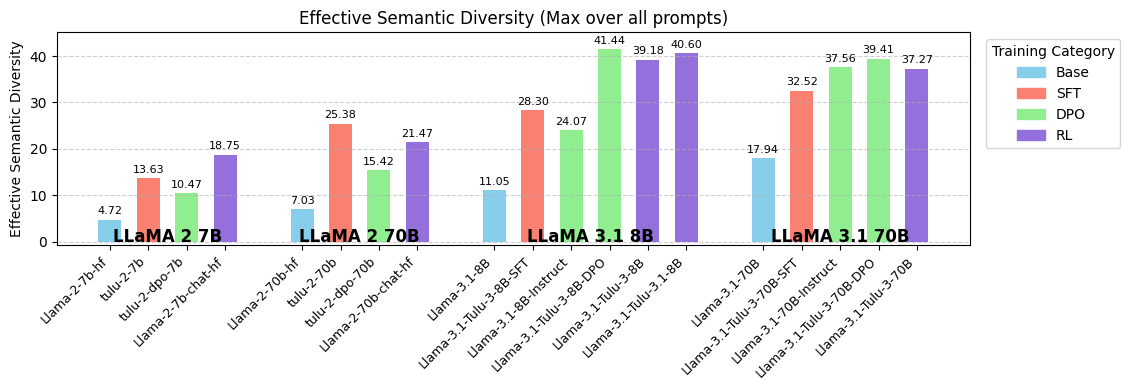

In [28]:
plot_metric_by_model_grouped(
    df=data,
    by_model_family=by_model_family,
    metric_col="all_coh_semantic_prop_of_all",
    title="Effective Semantic Diversity (Max over all prompts)",
    ylabel="Effective Semantic Diversity",
    aggregate_func="max"
)